# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "halon2402"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.448 0.45166666666666666 0.45533333333333337 ... 0.5 0.507 0.507] [0.448 0.45166666666666666 0.4536363636363636 ... 0.5015000000000001 0.507 0.507] [0.44799999999999995 0.45081818181818184 0.454 ... 0.5015000000000001 0.507 0.507] [0.448 0.45336363636363636 0.4587272727272727 ... 0.5015000000000001 0.507 0.507] [0.44799999999999995 0.45166666666666666 0.4561818181818182 ... 0.5012121212121212 0.507 0.507] [0.448 0.4516666666666667 0.4553333333333333 ... 0.5006363636363637 0.507 0.507]] [[0.465 0.463 0.461 ... 0.49533333333333335 0.498 0.5115000000000001] [0.465 0.463 0.4641818181818182 ... 0.49583333333333335 0.5036666666666667 0.5115000000000001] [0.465 0.4645909090909091 0.4687857142857143 ... 0.49837500000000007 0.5041666666666667 0.5115000000000001] [0.465 0.46654545454545454 0.46809090909090906 ... 0.49683333333333335 0.502625 0.5115000000000001] [0.465 0.463 0.4627727272727273 ... 0.49529166666666674 0.5010833333333333 0.5115000000000001] [0.465 0.463 0.461 ... 0.49375 0.4995416666666667 0.5115000000000001]] [[0.465 0.4666666666666667 0.4683333333333333 ... 0.50375 0.511 0.511] [0.465 0.4666666666666667 0.4666363636363636 ... 0.5035 0.511 0.511] [0.465 0.46581818181818185 0.46692857142857147 ... 0.5035000000000001 0.511 0.511] [0.465 0.4682727272727273 0.4715454545454545 ... 0.5035000000000001 0.511 0.511] [0.465 0.4666666666666667 0.46913636363636363 ... 0.5038484848484849 0.511 0.511] [0.465 0.4666666666666667 0.4683333333333333 ... 0.5045454545454545 0.511 0.511]] ... [[0.3825 0.3835 0.38450000000000006 ... 0.3995 0.398 0.39925] [0.3825 0.3835 0.38377272727272727 ... 0.3975 0.39837500000000003 0.39925] [0.3825 0.38313636363636366 0.3836607142857143 ... 0.3965 0.3978888888888889 0.39925] [0.3825 0.38397619047619047 0.385452380952381 ... 0.39642592592592596 0.3979166666666667 0.39925] [0.3825 0.3835 0.3847380952380952 ... 0.3963518518518519 0.39794444444444443 0.39925] [0.3825 0.3835 0.3845 ... 0.39627777777777773 0.3979722222222223 0.39925]] [[0.381 0.382 0.383 ... 0.395125 0.39575 0.39625] [0.381 0.382 0.3835263157894737 ... 0.393 0.394625 0.39625] [0.381 0.38226315789473686 0.3843157894736842 ... 0.396 0.39608333333333334 0.39625] [0.381 0.3825714285714286 0.3841428571428571 ... 0.3955 0.396 0.39625] [0.381 0.382 0.38328571428571434 ... 0.395 0.3959166666666667 0.39625] [0.381 0.382 0.383 ... 0.3945 0.3958333333333333 0.39625]] [[0.3785 0.3799166666666667 0.38133333333333336 ... 0.3947333333333334 0.3948 0.395] [0.3785 0.3799166666666666 0.3818201754385965 ... 0.393 0.394 0.395] [0.3785 0.3801600877192982 0.38255043859649124 ... 0.3935 0.3943111111111111 0.395] [0.3785 0.38013095238095235 0.38176190476190475 ... 0.39339074074074076 0.3944333333333334 0.395] [0.3785 0.3799166666666666 0.38144047619047616 ... 0.3932814814814815 0.39455555555555555 0.395] [0.3785 0.3799166666666667 0.3813333333333333 ... 0.3931722222222222 0.39467777777777774 0.395]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.4635 0.45158750000000003 0.45043750000000005 ... 0.47167499999999996 0.4785999999999999 0.47475] [0.4635 0.448 0.4514285714285714 ... 0.46925 0.472 0.47475] [0.4635 0.45586363636363636 0.45609090909090916 ... 0.46875 0.4679999999999999 0.47475] [0.4635 0.46344444444444444 0.46338888888888896 ... 0.463 0.4706499999999999 0.47475] [0.4635 0.4587625 0.45815972222222223 ... 0.46692 0.4732999999999999 0.47475] [0.4635 0.45517500000000005 0.45402500000000007 ... 0.47084 0.47594999999999993 0.47475]] [[0.449 0.45735000000000003 0.45475 ... 0.46981249999999997 0.473 0.4775] [0.449 0.461 0.4624285714285714 ... 0.47075 0.474125 0.4775] [0.449 0.4547272727272727 0.4541818181818182 ... 0.46425 0.4695 0.4775] [0.449 0.45066666666666666 0.45233333333333337 ... 0.464 0.47037499999999993 0.4775] [0.449 0.45005 0.4495833333333334 ... 0.466 0.47124999999999995 0.4775] [0.449 0.45370000000000005 0.4511 ... 0.468 0.47212499999999996 0.4775]] [[0.448 0.45335000000000003 0.45375 ... 0.4683541666666666 0.4753333333333333 0.4726] [0.448 0.455 0.45626190476190476 ... 0.4673333333333333 0.46996666666666664 0.4726] [0.44799999999999995 0.45145454545454544 0.45136363636363636 ... 0.4679999999999999 0.4665 0.4726] [0.448 0.44955555555555554 0.45111111111111113 ... 0.462 0.46870833333333334 0.4726] [0.44799999999999995 0.45005 0.4510277777777778 ... 0.4658666666666667 0.47091666666666665 0.4726] [0.448 0.45170000000000005 0.4521 ... 0.4697333333333333 0.47312499999999996 0.4726]] ... [[0.3825 0.3835 0.38450000000000006 ... 0.3995 0.398 0.39925] [0.3825 0.3835 0.38377272727272727 ... 0.3975 0.39837500000000003 0.39925] [0.3825 0.38313636363636366 0.3836607142857143 ... 0.3965 0.3978888888888889 0.39925] [0.3825 0.38397619047619047 0.385452380952381 ... 0.39642592592592596 0.3979166666666667 0.39925] [0.3825 0.3835 0.3847380952380952 ... 0.3963518518518519 0.39794444444444443 0.39925] [0.3825 0.3835 0.3845 ... 0.39627777777777773 0.3979722222222223 0.39925]] [[0.381 0.382 0.383 ... 0.395125 0.39575 0.39625] [0.381 0.382 0.3835263157894737 ... 0.393 0.394625 0.39625] [0.381 0.38226315789473686 0.3843157894736842 ... 0.396 0.39608333333333334 0.39625] [0.381 0.3825714285714286 0.3841428571428571 ... 0.3955 0.396 0.39625] [0.381 0.382 0.38328571428571434 ... 0.395 0.3959166666666667 0.39625] [0.381 0.382 0.383 ... 0.3945 0.3958333333333333 0.39625]] [[0.3785 0.3799166666666667 0.38133333333333336 ... 0.3947333333333334 0.3948 0.395] [0.3785 0.3799166666666666 0.3818201754385965 ... 0.393 0.394 0.395] [0.3785 0.3801600877192982 0.38255043859649124 ... 0.3935 0.3943111111111111 0.395] [0.3785 0.38013095238095235 0.38176190476190475 ... 0.39339074074074076 0.3944333333333334 0.395] [0.3785 0.3799166666666666 0.38144047619047616 ... 0.3932814814814815 0.39455555555555555 0.395] [0.3785 0.3799166666666667 0.3813333333333333 ... 0.3931722222222222 0.39467777777777774 0.395]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'halon2402' (lon: 6, lat: 12, year: 14, month: 12)> Size: 97kB
<Quantity([[[[0.4635     0.449      0.448      ... 0.44925    0.45033333
    0.44875   ]
   [0.45       0.4565     0.444      ... 0.44875    0.44466667
    0.44875   ]
   [0.44725    0.43675    0.43866667 ... 0.43       0.44033333
    0.44733333]
   ...
   [0.393      0.3925     0.39133333 ... 0.39       0.39366667
    0.38966667]
   [0.3925     0.393      0.39466667 ... 0.389      0.39133333
    0.389     ]
   [0.3975     0.3875     0.3845     ... 0.38666667 0.38233333
    0.3835    ]]

  [[0.4515875  0.45735    0.45335    ... 0.4431     0.45176667
    0.4519    ]
   [0.44803333 0.45025    0.451875   ... 0.44193333 0.44420833
    0.44235   ]
   [0.44326667 0.442775   0.4399     ... 0.43555    0.43844167
    0.43831667]
...
   [0.40325    0.40358333 0.40238333 ... 0.39983333 0.40133333
    0.40258333]
   [0.40375    0.402      0.40135    ... 0.39930556 0.39883333
    0.39648333]
   [0.39845    0.40038889 0.40027778 ... 0.39618333 0.39658333
    0.3985    ]]

  [[0.47475    0.4775     0.4726     ... 0.46475    0.466625
    0.4678    ]
   [0.465      0.466875   0.4685     ... 0.45575    0.45575
    0.4632    ]
   [0.460125   0.458875   0.4633     ... 0.452      0.4509
    0.452     ]
   ...
   [0.40333333 0.405      0.405      ... 0.399375   0.4
    0.4044    ]
   [0.405      0.4005     0.3996     ... 0.3965     0.39666667
    0.3947    ]
   [0.397375   0.39825    0.39783333 ... 0.39216667 0.3924
    0.39725   ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 112B 2010 2011 2012 2013 2014 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.4635 0.449 0.448 ... 0.3866666666666667 0.3823333333333333 0.3835] [0.45158750000000003 0.45735000000000003 0.45335000000000003 ... 0.3854458333333333 0.38576666666666665 0.38428333333333337] [0.45043750000000005 0.45475 0.45375 ... 0.3840625 0.384 0.3829166666666667] ... [0.47167499999999996 0.46981249999999997 0.4683541666666666 ... 0.39844999999999997 0.39816666666666667 0.39849999999999997] [0.4785999999999999 0.473 0.4753333333333333 ... 0.4024 0.4025 0.403] [0.47475 0.4775 0.4726 ... 0.39625 0.3961 0.40087500000000004]] [[0.4635 0.449 0.448 ... 0.3866666666666667 0.3823333333333333 0.3835] [0.448 0.461 0.455 ... 0.3855 0.3875 0.385] [0.4514285714285714 0.4624285714285714 0.45626190476190476 ... 0.38721428571428573 0.38923214285714286 0.3871607142857143] ... [0.46925 0.47075 0.4673333333333333 ... 0.4034999999999999 0.395 0.402] [0.472 0.474125 0.46996666666666664 ... 0.40191666666666664 0.3974 0.40325] [0.47475 0.4775 0.4726 ... 0.4003333333333334 0.3998 0.4045]] [[0.4635 0.449 0.44799999999999995 ... 0.3866666666666667 0.3823333333333333 0.3835] [0.45586363636363636 0.4547272727272727 0.45145454545454544 ... 0.38650490196078435 0.3853186274509804 0.38395454545454544] [0.45609090909090916 0.4541818181818182 0.45136363636363636 ... 0.3873480392156863 0.3861225490196078 0.38336363636363635] ... [0.46875 0.46425 0.4679999999999999 ... 0.39325 0.39175 0.4005] [0.4679999999999999 0.4695 0.4665 ... 0.401 0.4015 0.4025] [0.47475 0.4775 0.4726 ... 0.39216666666666666 0.39239999999999997 0.39725]] [[0.4635 0.449 0.448 ... 0.3866666666666667 0.3823333333333333 0.3835] [0.46344444444444444 0.45066666666666666 0.44955555555555554 ... 0.3869583333333334 0.3830416666666666 0.3838125] [0.46338888888888896 0.45233333333333337 0.45111111111111113 ... 0.38725000000000004 0.3837499999999999 0.38412500000000005] ... [0.463 0.464 0.462 ... 0.3835 0.3845 0.389] [0.4706499999999999 0.47037499999999993 0.46870833333333334 ... 0.38375000000000004 0.38475000000000004 0.3895] [0.47475 0.4775 0.4726 ... 0.384 0.385 0.39]] [[0.4635 0.449 0.44799999999999995 ... 0.3866666666666667 0.3823333333333333 0.3835] [0.4587625 0.45005 0.45005 ... 0.38533750000000005 0.3823 0.38284999999999997] [0.45815972222222223 0.4495833333333334 0.4510277777777778 ... 0.3847916666666667 0.3817708333333333 0.3823229166666667] ... [0.46692 0.466 0.4658666666666667 ... 0.3884833333333333 0.38905555555555554 0.3921666666666666] [0.4732999999999999 0.47124999999999995 0.47091666666666665 ... 0.3899666666666667 0.3906666666666667 0.394] [0.47475 0.4775 0.4726 ... 0.38808333333333334 0.3887 0.393625]] [[0.4635 0.449 0.448 ... 0.3866666666666667 0.3823333333333333 0.3835] [0.45517500000000005 0.45370000000000005 0.45170000000000005 ... 0.38539166666666674 0.38403333333333334 0.38356666666666667] [0.45402500000000007 0.4511 0.4521 ... 0.38400833333333334 0.38226666666666664 0.3822] ... [0.47084 0.468 0.4697333333333333 ... 0.3934666666666667 0.39361111111111113 0.3953333333333333] [0.47594999999999993 0.47212499999999996 0.47312499999999996 ... 0.39618333333333333 0.39658333333333334 0.3985] [0.47475 0.4775 0.4726 ... 0.39216666666666666 0.39239999999999997 0.39725]]]
Units,ppt


### Longitudinal-mean

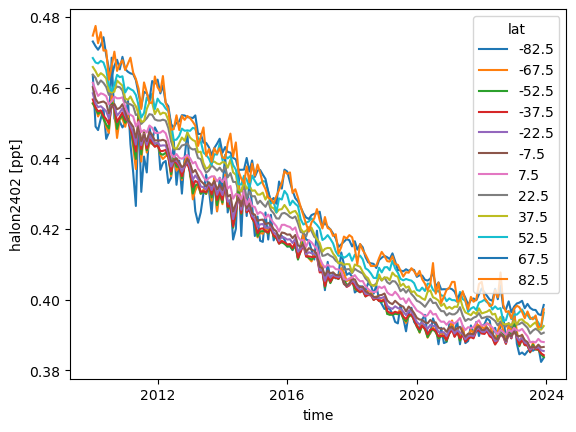

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

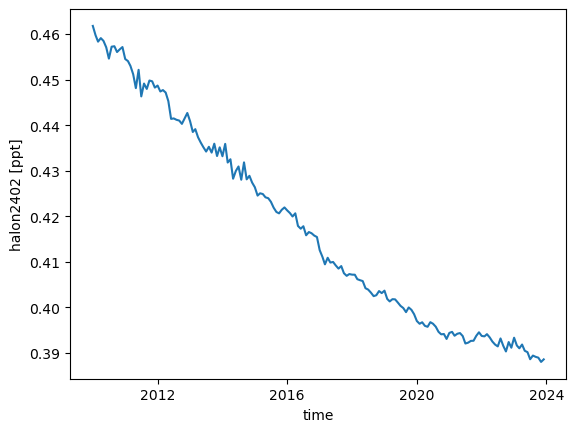

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

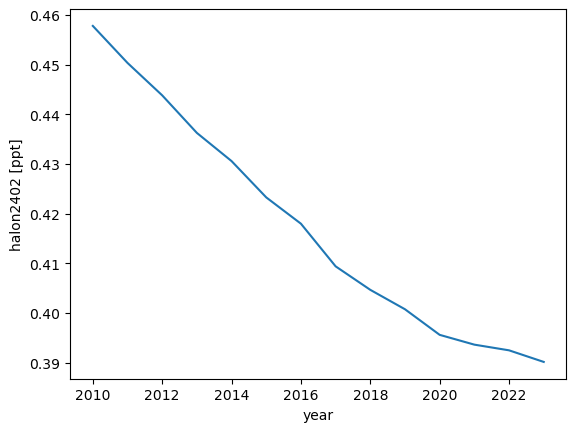

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

Magnitude,[[0.23102799931504586 0.8110030053006215 0.24831410450775543 0.434481644551129 0.1240616412309554 -0.06335553950859651 -0.10625969995171827 -0.04285292560398756 -0.05532409331681603 0.005485501541511906 0.0017094426309370856 -0.053287094834612816] [0.22605144797095264 0.38475753826136083 -0.03752265316206858 -0.5746215982290717 -0.34217858703503606 0.3321921133477764 0.2513909651019634 0.2288663762793465 0.22383445861100085 -0.22653765866342246 0.020505705520938076 -0.1562298570518831] [0.24506775186595822 0.11516639886915464 -0.22392962293808982 -0.34653470714051754 -0.06905085686335874 -0.22290931052835278 -0.09935156867219468 -0.24920854371421775 -0.22344603038286 0.7136606498794286 -0.09492509161526 -0.24852581269314508] [0.23518579519943808 -0.03636733957050121 -0.26674395008082297 -0.11260833644153385 0.14315632241638515 -0.3424083076183806 -0.14367352358111787 -0.20525301323266545 -0.24464323537211388 -0.6291618233210033 -0.3137316110709596 -0.32388514490761566] [0.1839302307125937 -0.08935724288911467 -0.1787302389403607 0.07213905013656943 0.14697020571659578 -0.16958273065663143 -0.07291053324127197 0.11063248721738284 0.18490301485639454 -0.04425602926205248 0.8214108326865709 -0.37717223974245545] [0.1325814648895796 -0.13997189379145594 -0.09270502325552703 0.2553809018418101 0.15513912565422142 -0.0008179043191404191 -0.006011906421401714 0.3981517029083531 0.5375835088839178 0.19028149387016458 -0.46621500491288587 -0.4047556697448733] [0.02447726725942466 -0.12266464813732408 -0.008114536485211737 0.23493811130997758 0.008927015460023963 0.4743577674093591 0.23047382744602052 0.24802156584106838 -0.6506384395478159 0.046681288494358826 0.005286432304687949 -0.4047556697451906] [-0.13279425874821857 -0.057392160381438614 0.17079088224474112 0.09694112063138939 -0.00017875101082865186 0.3026008658501301 0.23154499875732776 -0.7553288569093299 0.2863380870661833 -0.023458935648173133 -0.0019783199511310564 -0.3771722397421403] [-0.21750899251677033 -0.07181450195381103 0.3561483334734304 0.030800981652260265 -0.6050626754276325 -0.07456988949359587 -0.5786982226706673 0.07298292966647203 -0.029563866042461417 -0.045595202876957265 0.00282793644110873 -0.32388514490775383] [-0.35171284877302106 0.05954351618957429 0.43334390181630544 -0.17829465600910516 0.09921020777716591 -0.5352205137665001 0.51005180587706 0.16635582818819472 -0.08307733251518316 0.01891844339479515 -0.0045956389725373 -0.24852581269313184] [-0.5280731320390316 0.22730952154664186 -0.062310371133458546 -0.33619722646429656 0.5482083472880792 0.25528332534509823 -0.3957273215914984 0.0756801021712763 -0.0031201265958527907 0.010291124718292303 -0.002240842034287495 -0.15622985705194364] [-0.5105304066988149 0.2708508516645704 -0.6537201994977753 0.259779857182913 -0.34646321374021527 -0.1271600393312089 0.17683521181404527 -0.004599832194484023 0.02771831772932013 -0.007525337375242832 -0.0003340230861835838 -0.05328709483457271]]
Units,ppt
Magnitude,[[-0.021791623980046422 -0.0008287187955392672 -0.0015747461095909877 0.001205744782579791 0.00013335012427836358 0.00017262927382332455 -0.00011914738641110991 9.993588046332361e-05 1.1803603860301613e-05 -3.3215159704988368e-06 -3.547606695408562e-07 2.844738746229916e-19] [-0.020390977468095078 -0.0021617498297088955 -0.0018788499877950711 -0.0008553418255413709 -0.0003827439915061981 -5.077602519617215e-06 4.956321833459108e-05 -7.049448376993697e-05 -5.6994482726976195e-06 -3.1778879805463287e-06 1.4458712677557993e-06 1.2236844903408178e-17] [-0.019350493576757093 -0.0007210023317109199 -0.00020138017840601934 -0.0001690298062274818 -8.28171820930436e-05 -0.0002524827258236656 -0.00020616656880680318 -9.310232065599463e-05 1.546802056035795e-05 1.1141060550044373e-05 -1.008412671031502e-07 -2.5862325327271753e-17] [-0.019579857630213957 -0.002704294930977578 0.0006181972483957684 -0.0004172413879458585 0.00041109608900835896 -0.0002341771070073495 9.280332061943592e-05 0.000104327015

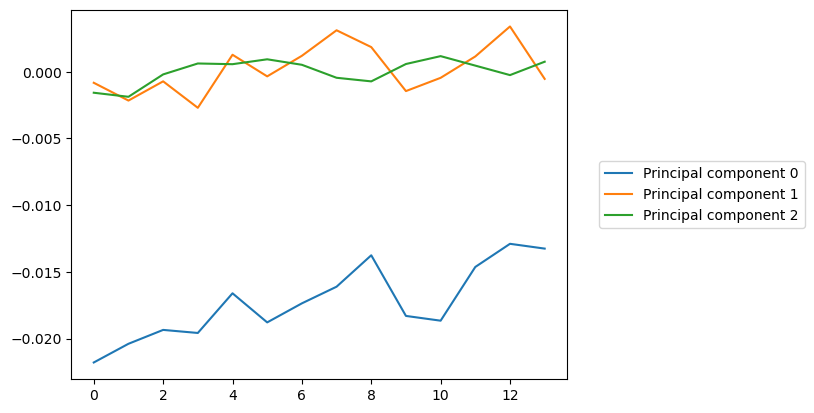

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

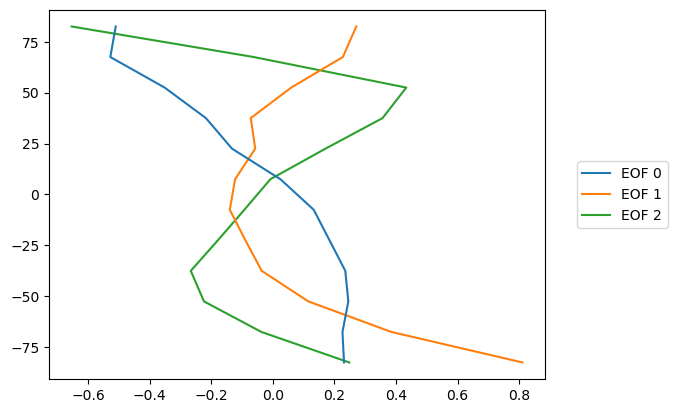

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

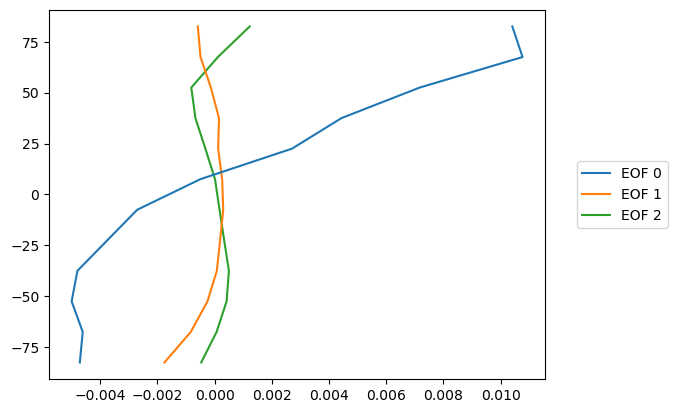

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.23102799931504586] [0.22605144797095264] [0.24506775186595822] [0.23518579519943808] [0.1839302307125937] [0.1325814648895796] [0.02447726725942466] [-0.13279425874821857] [-0.21750899251677033] [-0.35171284877302106] [-0.5280731320390316] [-0.5105304066988149]]
Units,ppt
Magnitude,[[-0.021791623980046422] [-0.020390977468095078] [-0.019350493576757093] [-0.019579857630213957] [-0.016606374209688076] [-0.018787375442254263] [-0.017360136404768918] [-0.016112160783287068] [-0.013757594576319912] [-0.01830266791448792] [-0.018659415365852822] [-0.01463236983447021] [-0.012897585771893096] [-0.013256748154740677]]
Units,dimensionless


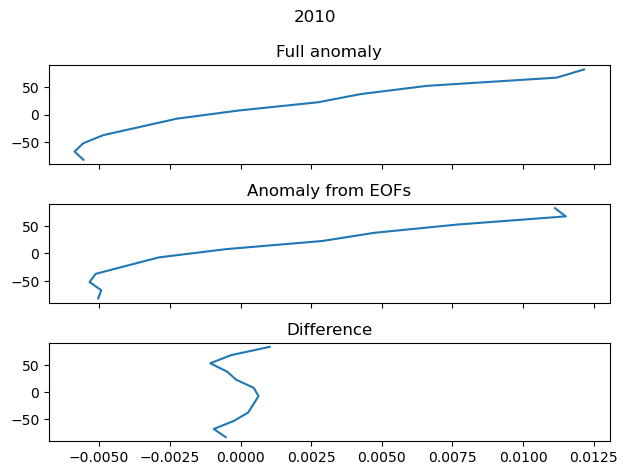

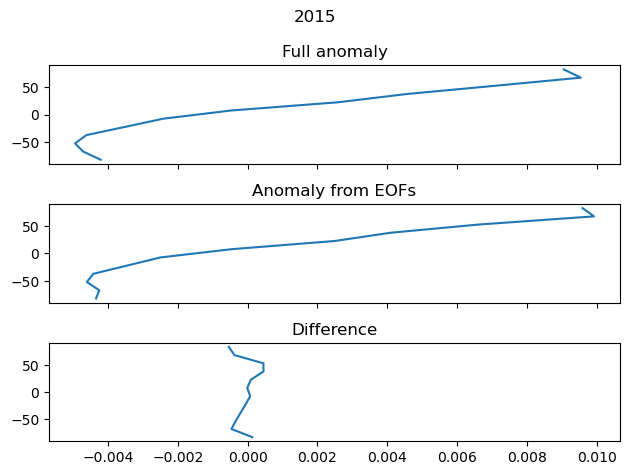

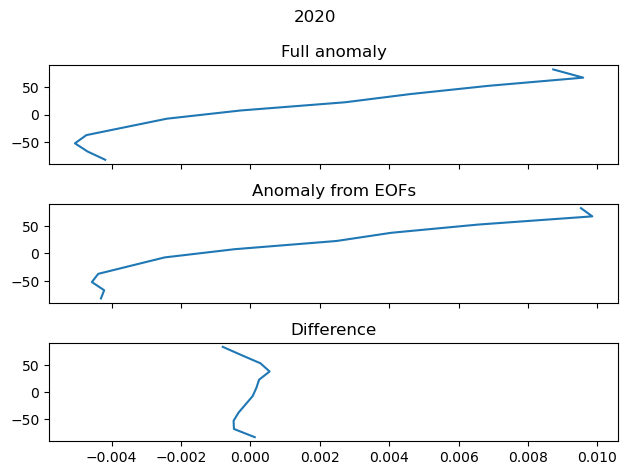

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 168/168 [00:00<00:00, 15191.18it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 168/168 [00:00<00:00, 19167.18it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 168/168 [00:00<00:00, 19328.06it/s]

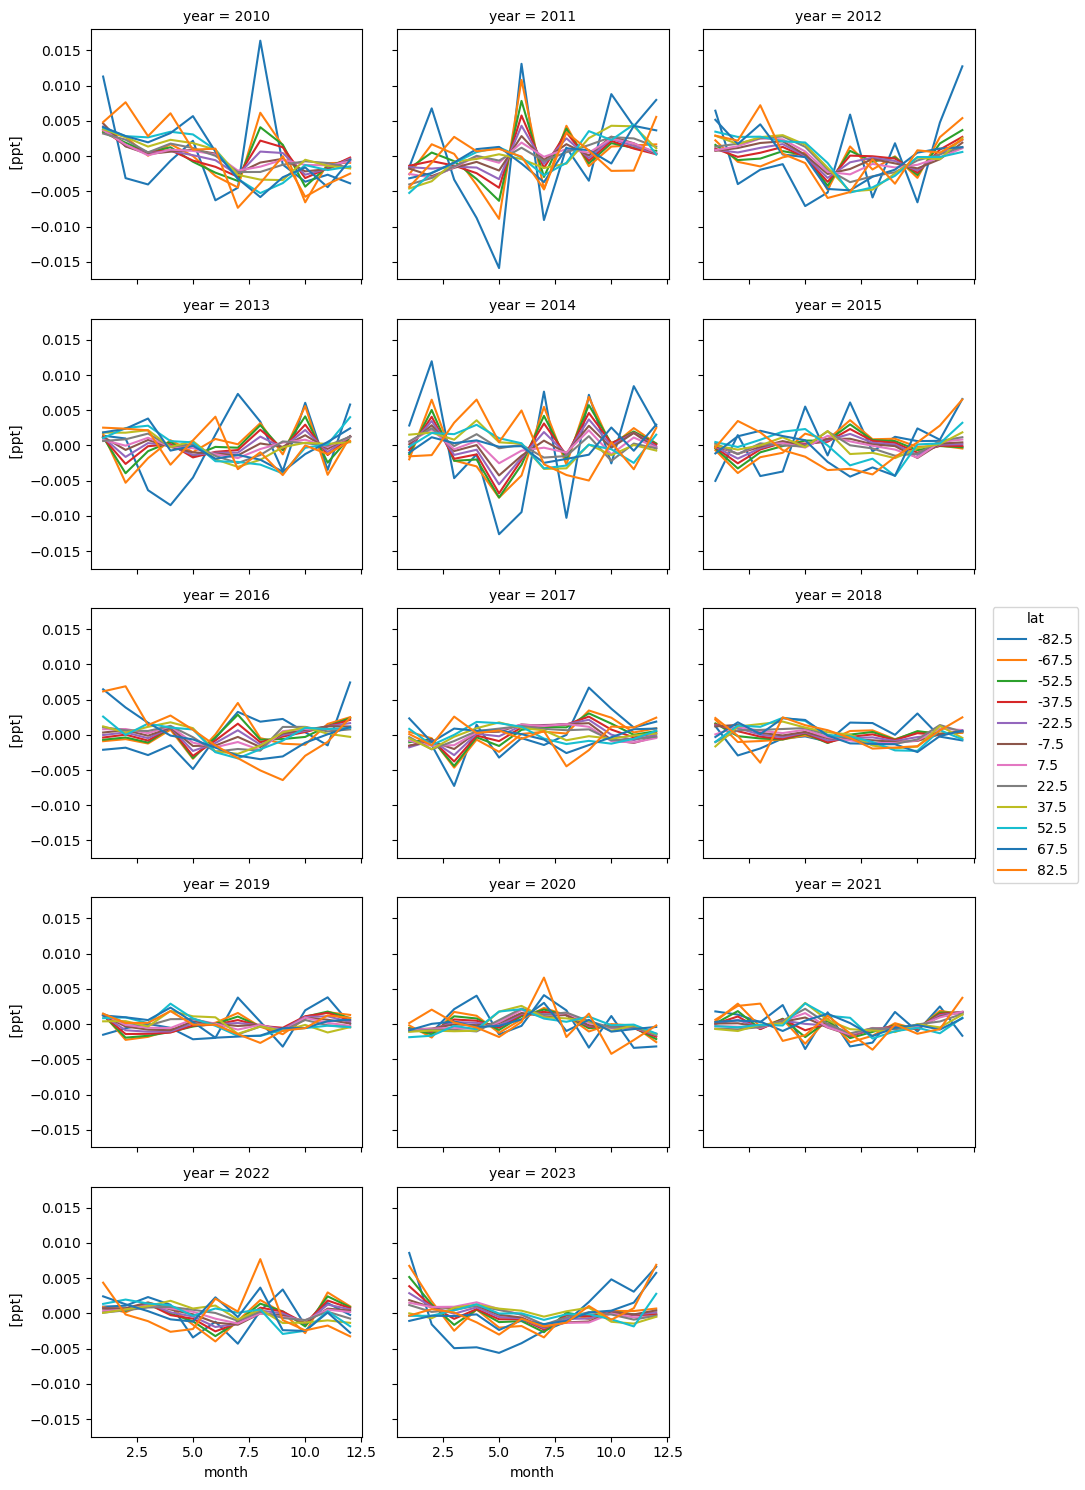

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

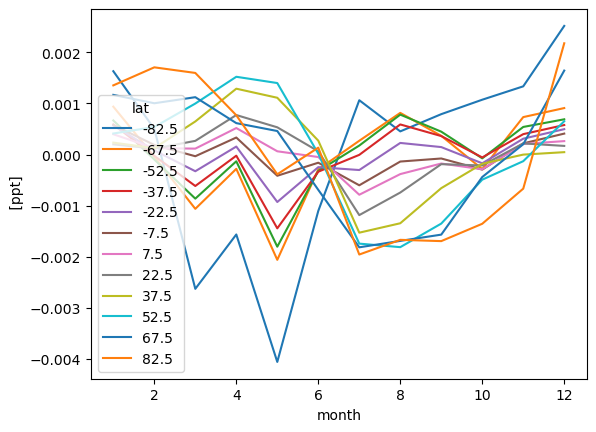

In [22]:
seasonality.plot.line(hue="lat")

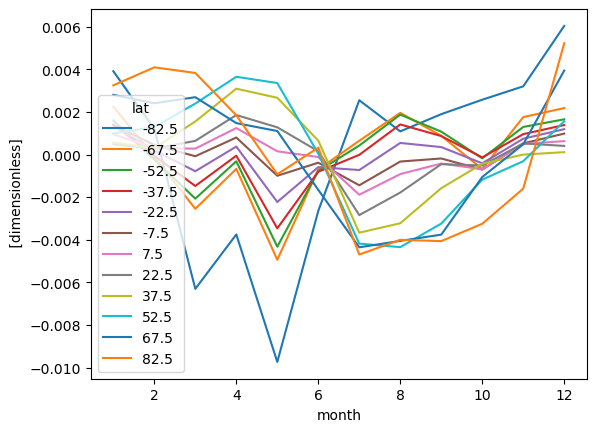

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[0.4577895802994478 0.45033746619870185 0.4438075851476695 0.43624104606308434 0.43056630927200584 0.42325426646451914 0.41795571409931725 0.40936917244007165 0.4046360402566636 0.4007244970306409 0.39557168460103426 0.39359949185140675 0.39245433356325116 0.39011978611174863]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.23102799931504586] [0.22605144797095264] [0.24506775186595822] [0.23518579519943808] [0.1839302307125937] [0.1325814648895796] [0.02447726725942466] [-0.13279425874821857] [-0.21750899251677033] [-0.35171284877302106] [-0.5280731320390316] [-0.5105304066988149]]
Units,ppt
Magnitude,[[-0.021791623980046422] [-0.020390977468095078] [-0.019350493576757093] [-0.019579857630213957] [-0.016606374209688076] [-0.018787375442254263] [-0.017360136404768918] [-0.016112160783287068] [-0.013757594576319912] [-0.01830266791448792] [-0.018659415365852822] [-0.01463236983447021] [-0.012897585771893096] [-0.013256748154740677]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.00391002226424583 0.0012021199244611203 -0.006306564000508886 -0.003754496086432999 -0.009737305498900624 -0.0026485984891186443 0.00254788122339871 0.0010852579651768033 0.0018939167153826752 0.002571994102679757 0.003199694651766432 0.006036121445514825] [0.0022456530538393794 -0.00010426197899797765 -0.0025503674126398502 -0.0006741908227650184 -0.004944868666470882 -0.0007000731925892799 0.0006451053305456551 0.0019540571107339974 0.0008764053708962002 -0.0006832146231016016 0.001755874278390099 0.002179902265370861] [0.001598075148680006 -0.00023569034760877856 -0.0020713635327669518 -0.0003192263028485138 -0.004327397434789717 -0.0007734209553520775 0.0004195358333319089 0.0018716428690451513 0.0010720976237382459 -0.00017973795030275965 0.0012931778279067201 0.001652321934294614] [0.0014091248638747487 -6.333258798077005e-05 -0.001478118765641659 -5.573946109693508e-05 -0.0034660336452343784 -0.0008075136872558196 -1.6607762683616514e-05 0.0014114272481655253 0.0008658673470287774 -0.00013824192897729425 0.0009556840622203203 0.0013834959770041152] [0.0013627107061161038 0.00019301986811224933 -0.0007853525719958936 0.0003732110797799557 -0.0022298823103669204 -0.0005943127251585128 -0.0007288555351826133 0.0005427457159395695 0.00034843707736413213 -0.0004133109353403511 0.0007416787658301609 0.0011899206611955307] [0.0013879541617952613 0.000448562783405959 -8.14638467695187e-05 0.0007969195275466822 -0.0009979272780787302 -0.00038532899721668276 -0.001445412548910285 -0.00033041073835142677 -0.00018723987233532947 -0.0007083608743937762 0.0005216852301147254 0.0009810303677004195] [0.0009518709415082799 0.0002996608174101367 0.00027604858065679384 0.0012414536246548834 0.0001512371606414674 -0.00011872660187795579 -0.0018892483648362153 -0.0009199273587099625 -0.00042373057435733815 -0.0006931909968360566 0.0004960525866254553 0.0006285047254903403] [0.00047673968702767184 0.00027569368974903515 0.0006404069405884122 0.001852486120472965 0.0012764033555996079 0.00015168716657538178 -0.0028447697829506852 -0.001785601602066006 -0.0004536212823870504 -0.0005140408500913066 0.0005213355967261928 0.00040328480071743193] [0.0005576267554709554 0.0002963715416886194 0.001551072341922838 0.0030895322977514436 0.002663513563925834 0.0006498243838907181 -0.0036697295329730455 -0.0032279741741232195 -0.001579872991563598 -0.0004351126733410936 -5.0073521702706826e-06 0.00010975479040265265] [0.000984488452555589 0.0012922446965336846 0.002391897732339556 0.003648609118525508 0.003354285957536285 3.844058292872907e-05 -0.004184262571257549 -0.004349361378945398 -0.00324317988109055 -0.0011811143188231001 -0.00031394154739887686 0.001561900323045627] [0.002798841068127914 0.0024053986718145706 0.0026907962931547085 0.0014729205532308615 0.0011025141139105687 -0.0016599474938985867 -0.004357259362338891 -0.00405562123611249 -0.003761624626474885 -0.0010568636548988178 0.000481164686199911 0.003939705119674343] [0.0032452321625194396 0.004091884188976596 0.0038287722976639285 0.0018420773617792306 -0.0009288805630063504 0.0003227691290303824 -0.004695320415385595 -0.004006340367909323 -0.004066082237075064 -0.0032517195420757876 -0.001603470060190827 0.005221102473678242]]
Units,dimensionless
